# Prerequisites

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('darkgrid')
plt.rcParams['figure.dpi'] = 300

## Main df

In [2]:
# Import data
df_main = pd.read_excel('../data/df_main.xlsx')
display(df_main.head())
df_main.info()

,test,net_impact,splashing,splashing_spectrum,breaking_up,rebound,one_drop,voltage,long_impulse_duration,long_impulse_dur_binary,...,inclination,roughness_binary,particle_liquid_density_ratio,volume_fraction_binary,particle_diameter_cat,particle_droplet_diameter_ratio,velocity,Re,We,We_Re
0,3,0,1,2,0,0,1,105.0,10,low,...,0,0,1.219512,1,small,0.013301,3.961141,1492.516020,1492.302356,240.108847
1,4,0,1,2,0,0,1,105.0,10,low,...,0,0,1.219512,1,small,0.013301,3.961141,1492.516020,1492.302356,240.108847
2,5,0,1,2,0,0,1,105.0,10,low,...,0,0,1.219512,1,small,0.013301,3.961141,1492.516020,1492.302356,240.108847
3,7,0,1,2,0,0,0,105.0,10,low,...,0,0,1.219512,1,small,0.013833,3.961141,1435.111557,1434.906112,233.148786
4,8,0,1,2,0,0,0,105.0,10,low,...,0,0,1.219512,1,small,0.013833,3.961141,1435.111557,1434.906112,233.148786


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 372 entries, 0 to 371
Data columns (total 30 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   test                             372 non-null    int64  
 1   net_impact                       372 non-null    int64  
 2   splashing                        372 non-null    int64  
 3   splashing_spectrum               372 non-null    int64  
 4   breaking_up                      372 non-null    int64  
 5   rebound                          372 non-null    int64  
 6   one_drop                         372 non-null    int64  
 7   voltage                          372 non-null    float64
 8   long_impulse_duration            372 non-null    int64  
 9   long_impulse_dur_binary          372 non-null    object 
 10  wettability                      372 non-null    object 
 11  roughness                        372 non-null    float64
 12  liquid_density        

### Wettability to ordinal

Change wettability to ordinal feature

In [3]:
print('Wettability before encoding')
print(df_main['wettability'].value_counts())
print()

wettability_dict = {
    'lyophilic': 0,
    'neutral': 1,
    'lyophobic': 2,
}

print('Wettability after encoding')
df_main['wettability'] = df_main['wettability'].map(wettability_dict)
print(df_main['wettability'].value_counts())

Wettability before encoding
wettability
lyophilic    147
neutral      114
lyophobic    111
Name: count, dtype: int64

Wettability after encoding
wettability
0    147
1    114
2    111
Name: count, dtype: int64


### Labels description:

- **splashing_spectrum**: 
    - **0 - no splashing**, when *'Number of detached small droplets during Spreading' == 0*
    - **1 - semi splashing**, when **gear** occurs, or when few droplets detach
    - **2 - splashing**. Pure splashing, when **many** droplets or **many small** droplets detach
    
- **splashing**: 1 - when *'Number of detached small droplets during Spreading' != 0*;
- **breaking_up**: when *'Number of detached small droplets during Receding or Rim merging' > 0*
- **rebound** consists of next cases:
    - **2 - true rebound**, when droplets detaching during partial rebound, or when droplet rebounds totally.
    
    *True rebound: 'Rebound' == 2 OR ('Rebound' == 1 AND 'Number of detached droplets during Rebound' > 0)*
    - **1 - jet ejection**, when true rebound does not appear.

    *'Rim merging or Central jet ejecting' == 2 AND NOT True rebound*    
    - **0** - no true rebound and no jet ejection. *Other cases*

- **net_impact**: when there is 
    - **no Splashing** (no small droplets detached during spreading, *'Number of detached small droplets during Spreading'==0*), 
    - **no Breaking up** (when *'Number of detached small droplets during Receding or Rim merging' == 0*)
    - **no True Rebound** (see True rebound definition early)

### Physical properties

$velocity = \sqrt{2g\cdot height}$

$Re=\frac{velocity \cdot droplet\_diameter \cdot liquid\_density}{viscosity}$

$We=\frac{velocity^2 \cdot droplet\_diameter \cdot liquid\_density}{surface\_tension}$

$We\_Re = We^{1/2}Re^{1/4}$

particle_droplet_diameter_ratio = particle_mean_diameter / droplet_diameter

particle_liquid_density_ratio = particle_density / liquid_density

*Params above were checked*

### Main column groups 
(see edit_labels.ipynb)

In [4]:
targets = ['net_impact', 'splashing']
impact_labels = ['splashing_spectrum', 'breaking_up', 'rebound']

# Unnecesary to model
generation_features = [
    'one_drop', 'voltage', 'long_impulse_duration', 'long_impulse_dur_binary'
]

# do not forget 'test'
features_original = [
    'wettability', 'roughness', 'liquid_density', 'surface_tension', 
    'viscosity', 'particle_mean_diameter', 'particle_density', 
    'volume_fraction', 'droplet_diameter', 'height', 'inclination'
]

features_aggregated = [
    'roughness_binary', 'particle_liquid_density_ratio', 
    'volume_fraction_binary', 'particle_diameter_cat', 
    'particle_droplet_diameter_ratio', 
    'velocity', 'Re', 'We', 'We_Re'
]

Labels correlation

<Axes: >

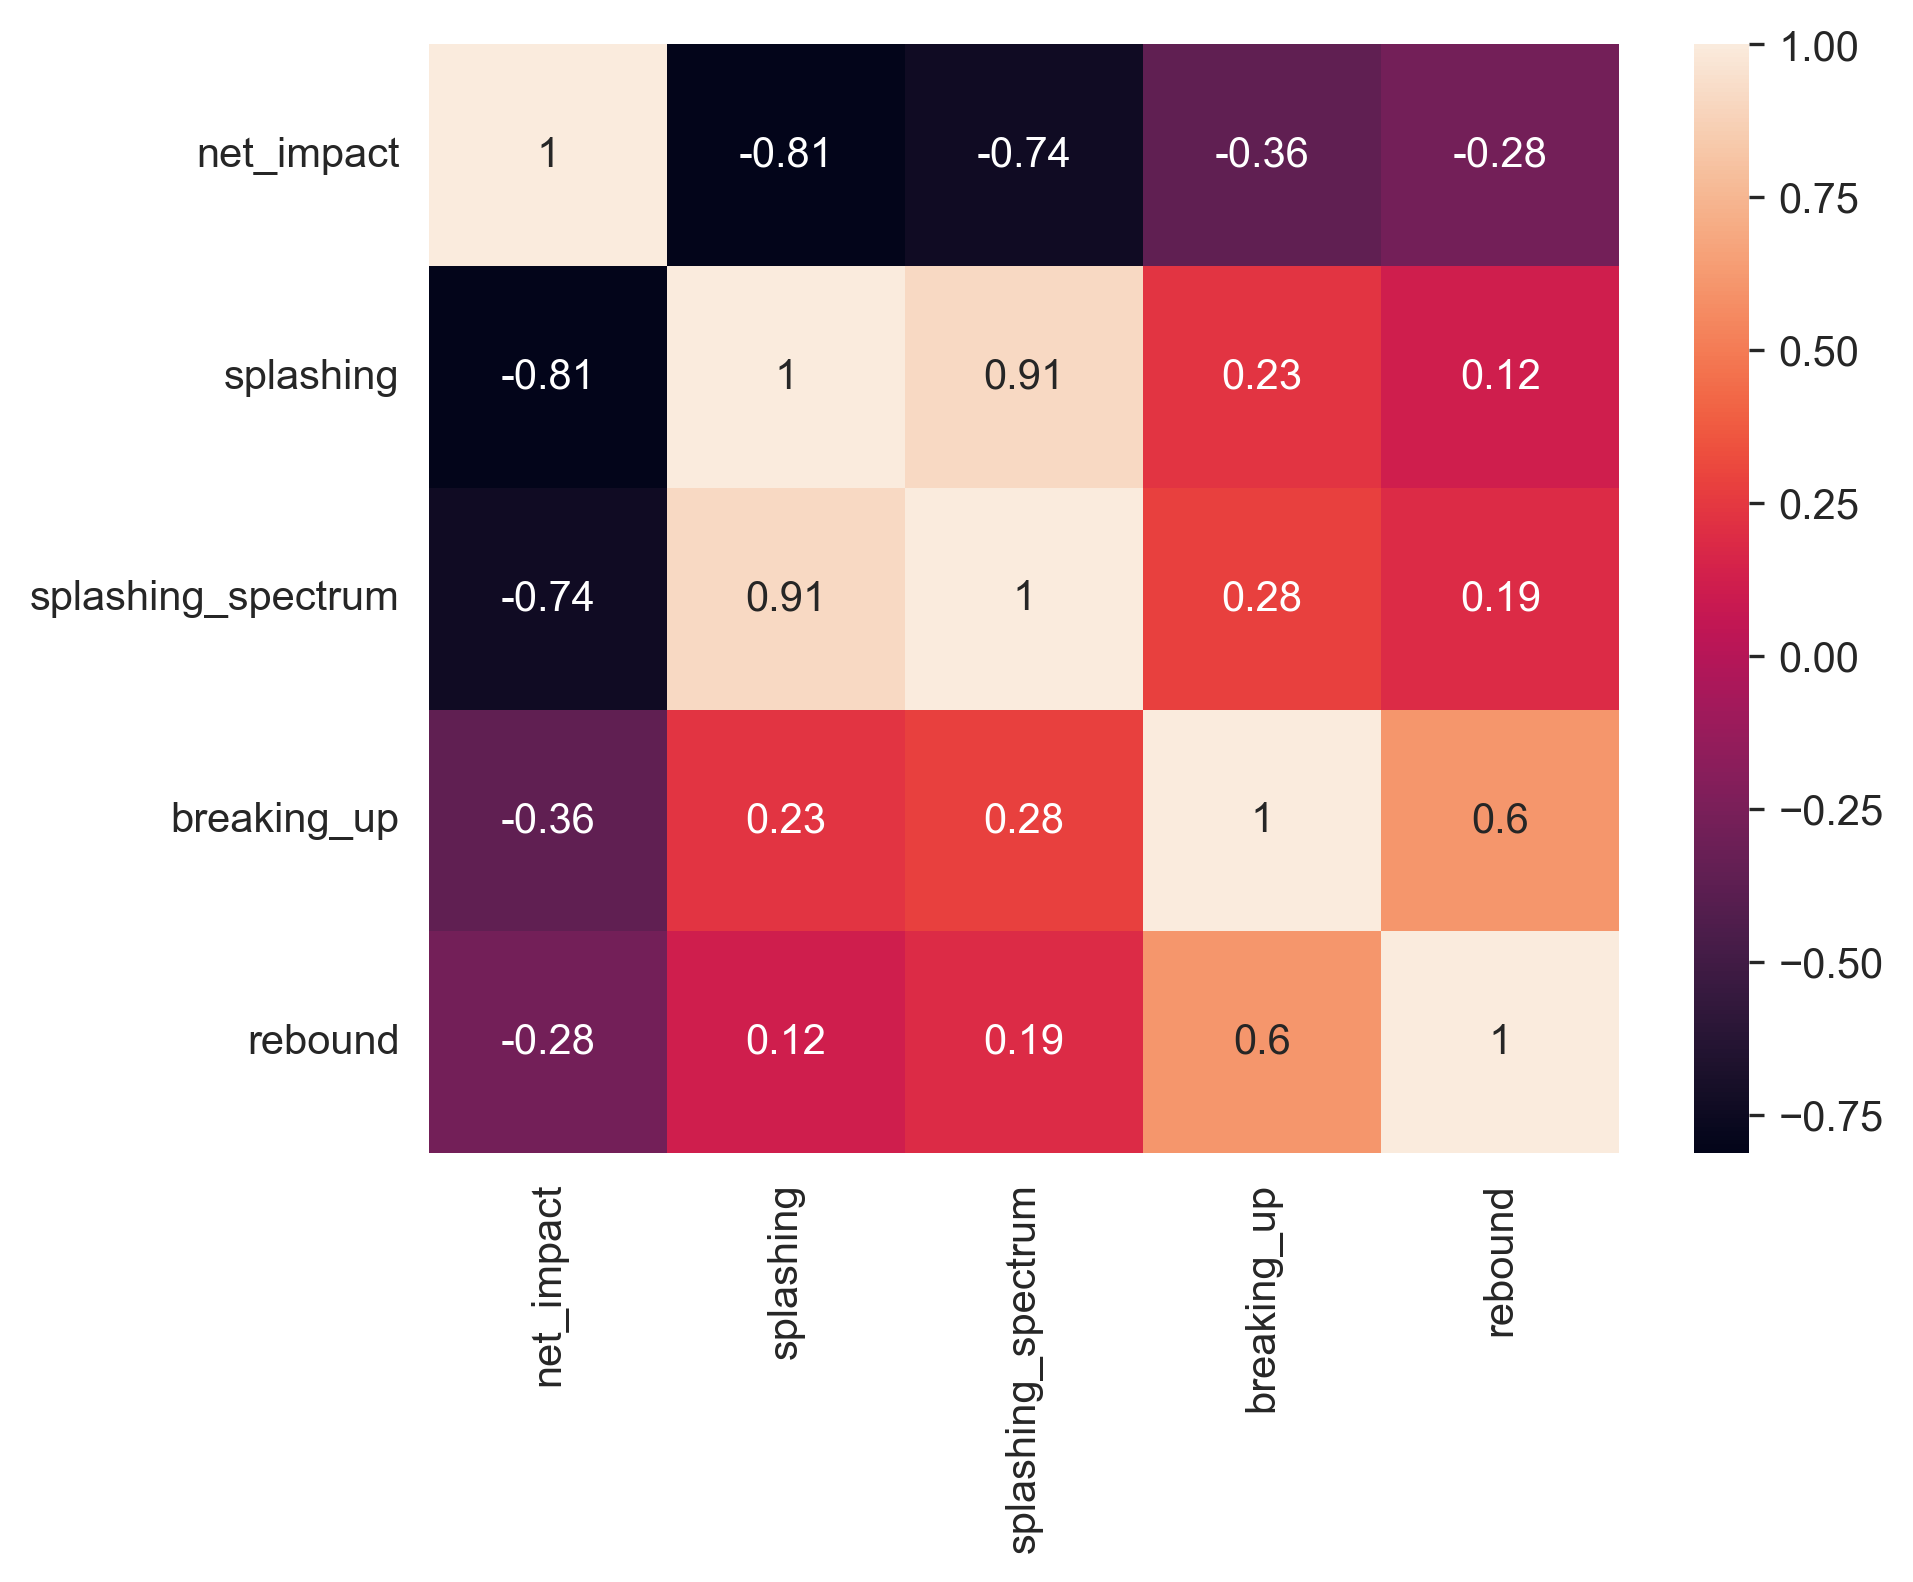

In [5]:
sns.heatmap(
    df_main[targets + impact_labels].corr(method='spearman'), 
    annot=True
)

## Prepare datasets for modelling

In [6]:
features_to_drop = (
    [
        'test', # not informative
        'height', # velocity is more informative
        'particle_diameter_cat', # necessary only for bar visualization
        'volume_fraction', # 0.04 and 0.05 are the same group of low volume fraction, as well as 0.08 and 0.10
    ] 
    + impact_labels
    + generation_features
)

df_modelling = df_main.drop(features_to_drop, axis=1)
df_modelling.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 372 entries, 0 to 371
Data columns (total 19 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   net_impact                       372 non-null    int64  
 1   splashing                        372 non-null    int64  
 2   wettability                      372 non-null    int64  
 3   roughness                        372 non-null    float64
 4   liquid_density                   372 non-null    int64  
 5   surface_tension                  372 non-null    float64
 6   viscosity                        372 non-null    float64
 7   particle_mean_diameter           372 non-null    float64
 8   particle_density                 372 non-null    int64  
 9   droplet_diameter                 372 non-null    float64
 10  inclination                      372 non-null    int64  
 11  roughness_binary                 372 non-null    int64  
 12  particle_liquid_densit

### Save full dataset

In [7]:
df_modelling.to_excel('../data/df_modelling_full.xlsx', index=False)

### Feature selection

Let us consider correlation heatmap

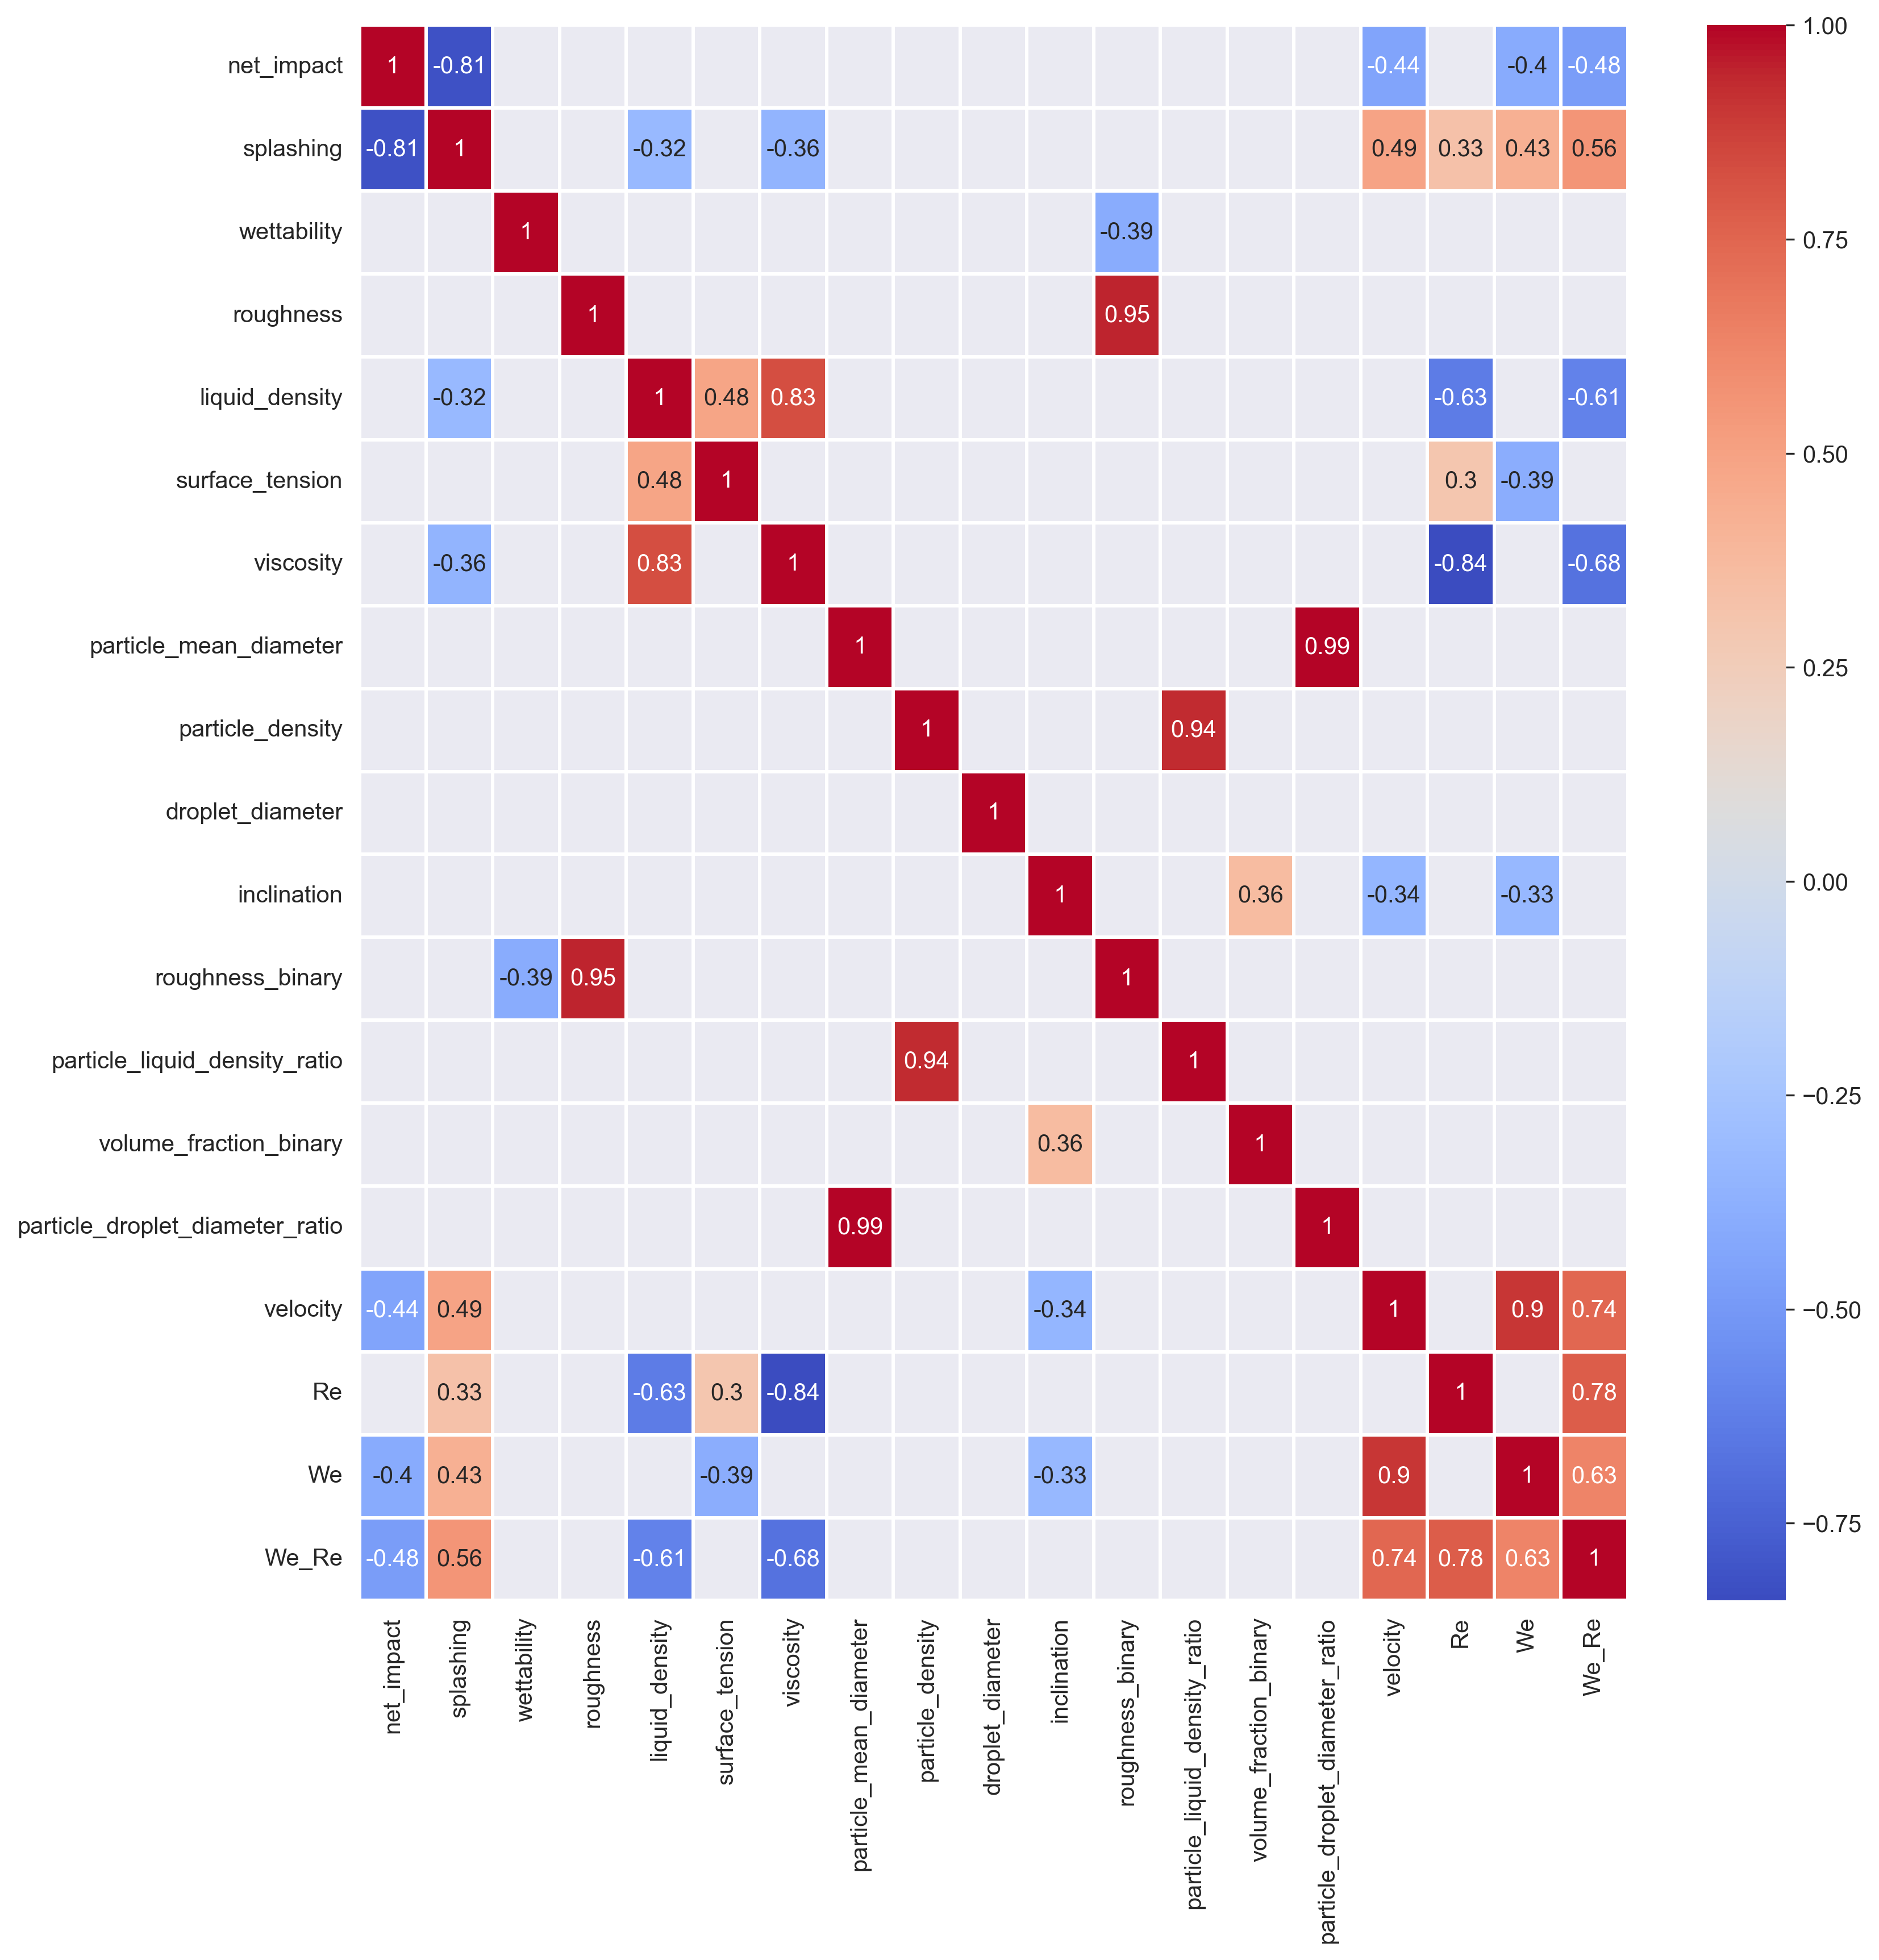

In [8]:
def get_corrmap(df, thresh = 0.3, ax=None, figsize=(12, 12)):
    corr = df.corr()
    if ax==None:
        fig, ax = plt.subplots(figsize=figsize)
    if thresh:
        corr = corr[np.abs(corr)>thresh]
    sns.heatmap(corr, annot=True, cmap='coolwarm', ax=ax, linewidths=1)
    ax.grid(False)

get_corrmap(df_modelling)

Candidates to drop:
- **'particle_mean_diameter' or 'particle_droplet_diameter_ratio'**: 0.99
- **'particle_density' or 'particle_liquid_density_ratio'**: 0.94. Better to drop 'particle_density'
- **'roughness' or 'roughness_binary'**: 0.95. Better to drop roughness
- **'velocity' or 'We'**: 0.9. Better to drop 'velocity', since implicitly it is on the We and Re

Also:
- 'viscosity' or 'liquid_density': 0.83, since they are same for the same liquid. *Better to drop "liquid_density", since models do not choose liquid density?*
- 'viscosity' or 'Re': -0.84.


Let us drop multicollinear features (abs value 0.9 and higher)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 372 entries, 0 to 371
Data columns (total 15 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   net_impact                       372 non-null    int64  
 1   splashing                        372 non-null    int64  
 2   wettability                      372 non-null    int64  
 3   liquid_density                   372 non-null    int64  
 4   surface_tension                  372 non-null    float64
 5   viscosity                        372 non-null    float64
 6   droplet_diameter                 372 non-null    float64
 7   inclination                      372 non-null    int64  
 8   roughness_binary                 372 non-null    int64  
 9   particle_liquid_density_ratio    372 non-null    float64
 10  volume_fraction_binary           372 non-null    int64  
 11  particle_droplet_diameter_ratio  372 non-null    float64
 12  Re                    

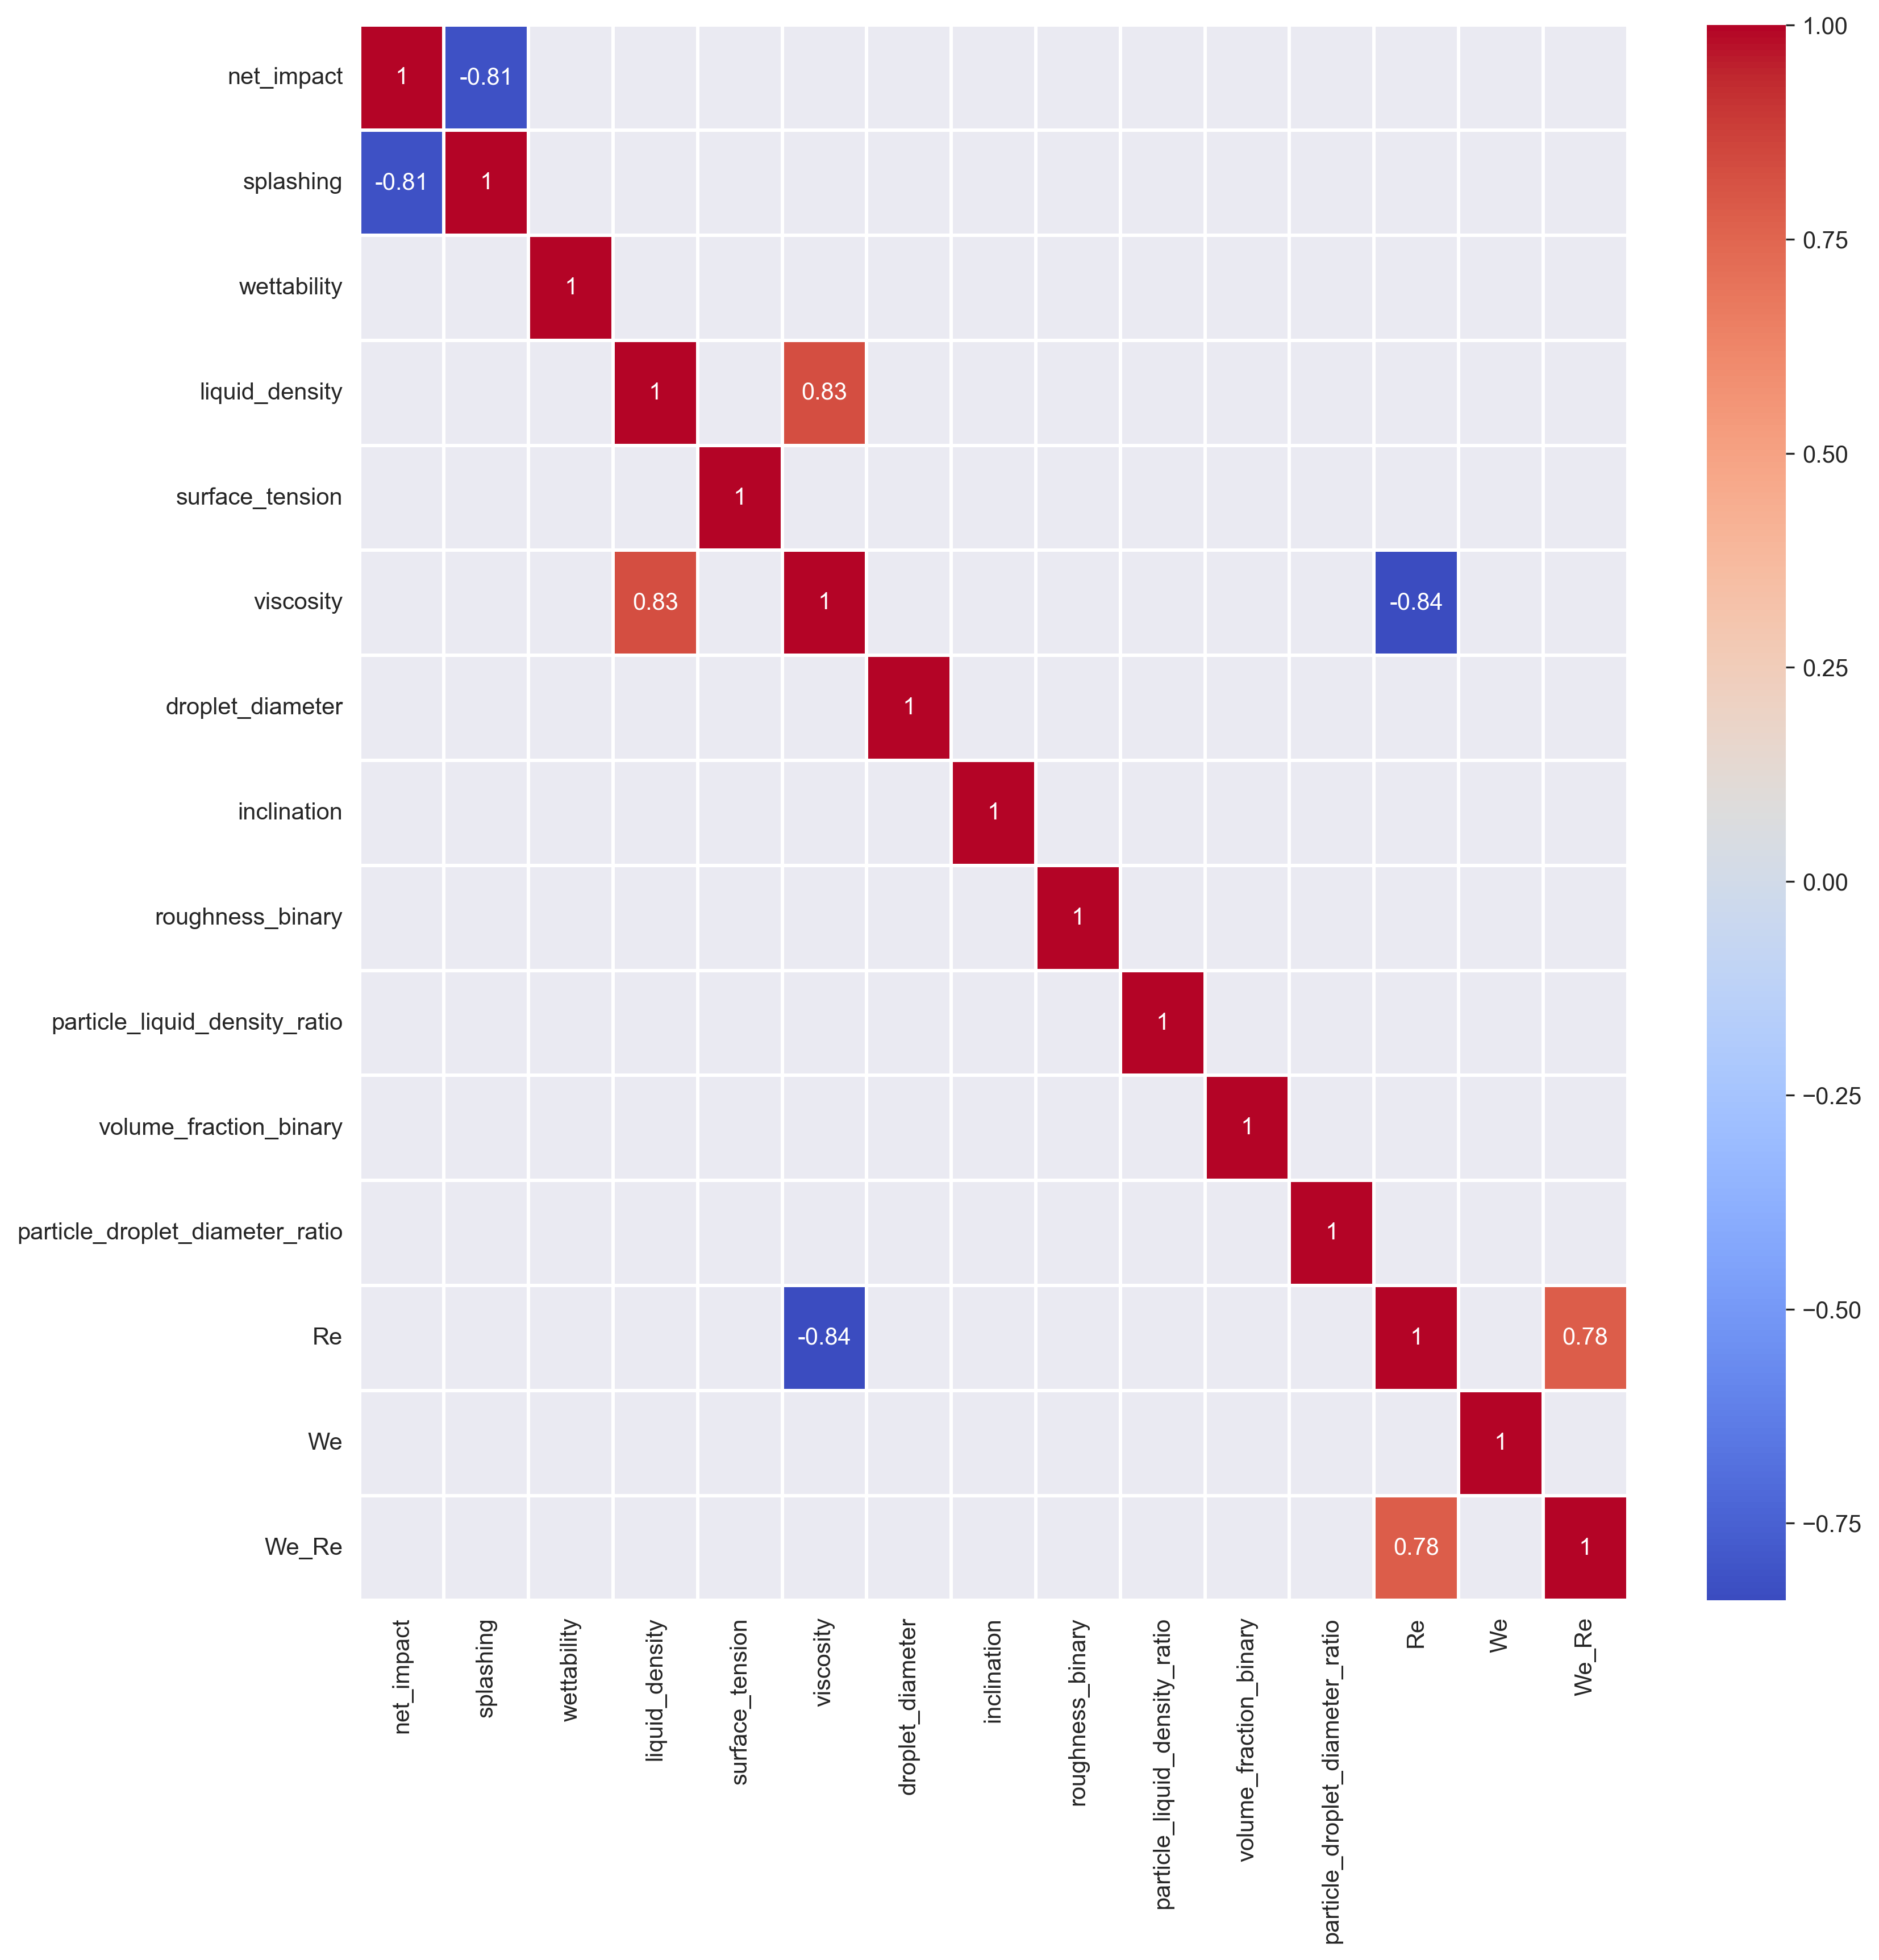

In [9]:
most_corr_features_to_drop = [
    'particle_mean_diameter',
    'particle_density', # particle_liquid_density_ratio is choosen
    'roughness', # roughness_binary is better to categorize glass roughness
    'velocity', # implicitly it is on the We and Re
    # 'viscosity' # has high correlation with liquid_density and 'Re'
] 

df_modelling_no_corr = df_modelling.drop(most_corr_features_to_drop, axis=1)
df_modelling_no_corr.info()
get_corrmap(df_modelling_no_corr, thresh=0.75)

Droplet diameter:

<Axes: ylabel='Frequency'>

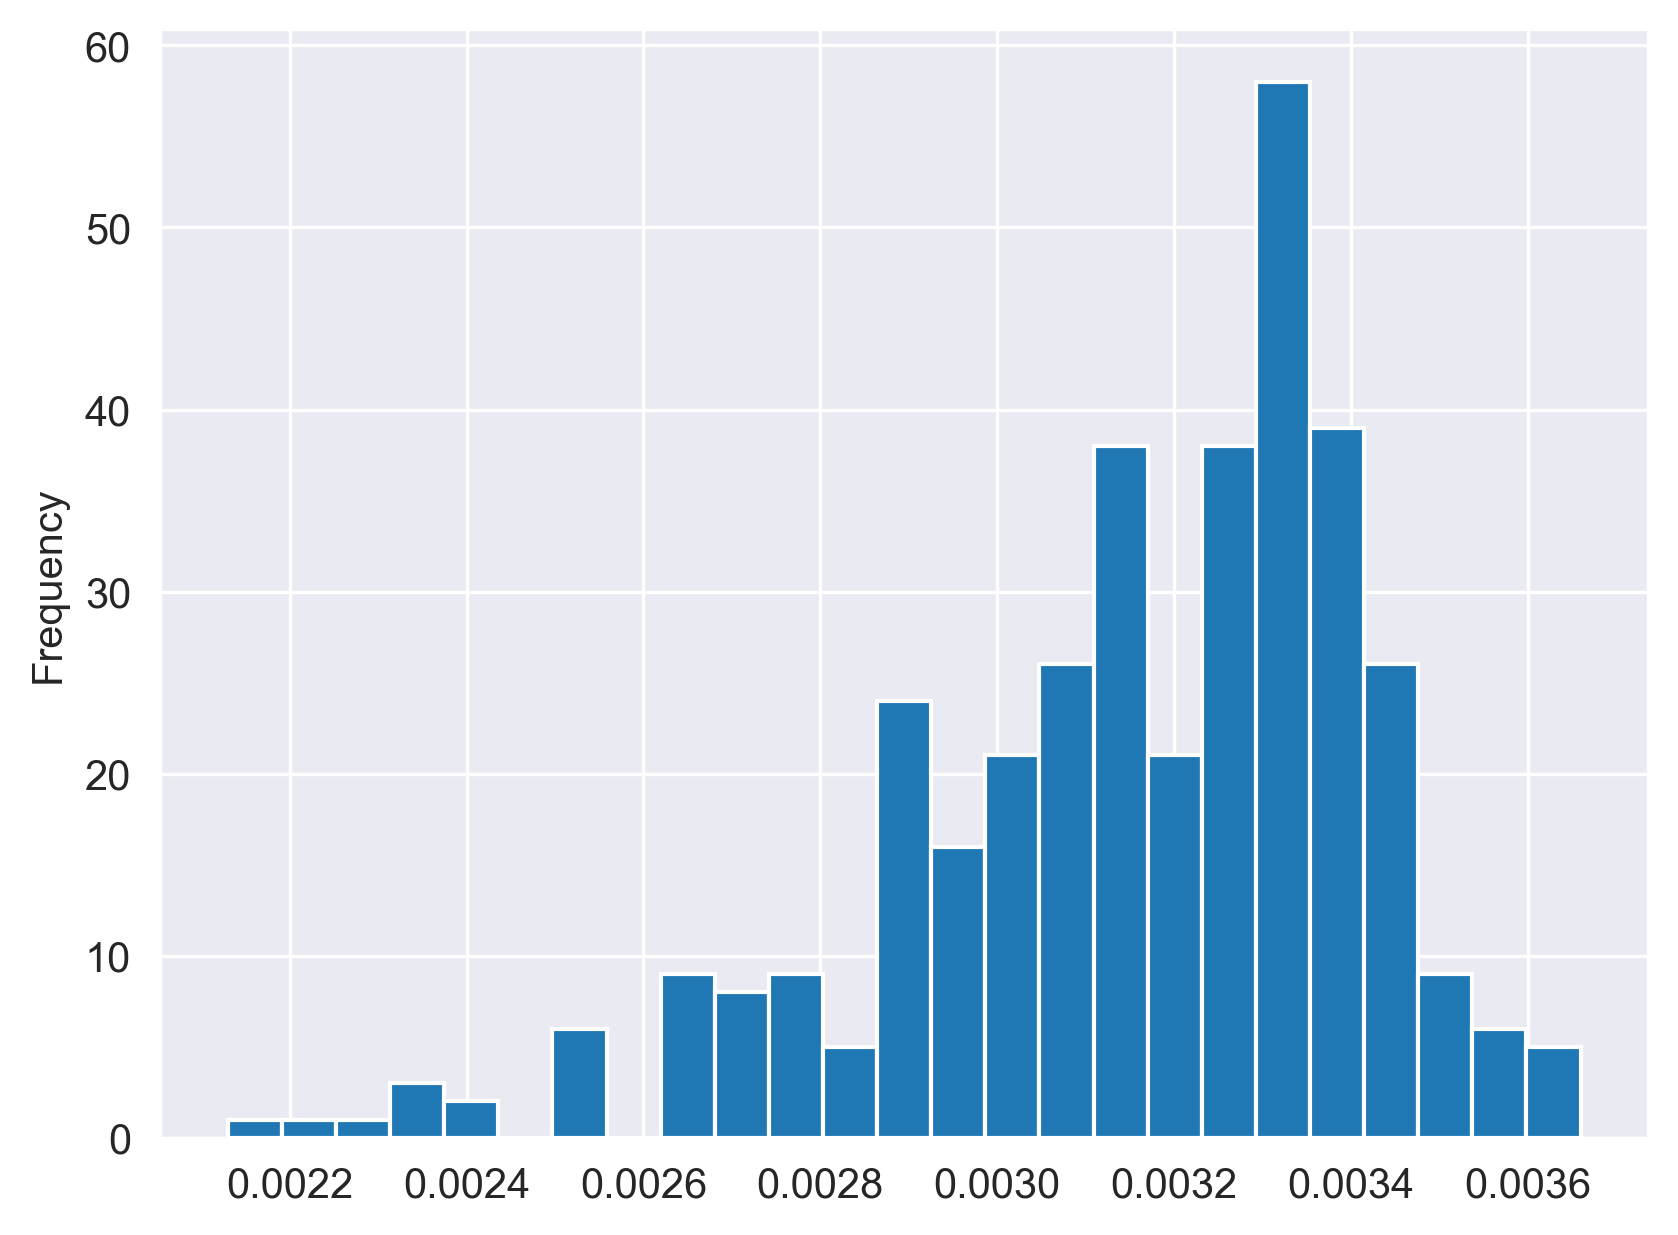

In [10]:
df_main['droplet_diameter'].plot.hist(bins=25)

### Save dataset without multicorrelation

In [11]:
df_modelling_no_corr.to_excel('../data/df_modelling_no_multicollinearity.xlsx', index=False)

### Dimensionless modelling

Used to get generalized model

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 372 entries, 0 to 371
Data columns (total 11 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   net_impact                       372 non-null    int64  
 1   splashing                        372 non-null    int64  
 2   wettability                      372 non-null    int64  
 3   inclination                      372 non-null    int64  
 4   roughness_binary                 372 non-null    int64  
 5   particle_liquid_density_ratio    372 non-null    float64
 6   volume_fraction_binary           372 non-null    int64  
 7   particle_droplet_diameter_ratio  372 non-null    float64
 8   Re                               372 non-null    float64
 9   We                               372 non-null    float64
 10  We_Re                            372 non-null    float64
dtypes: float64(5), int64(6)
memory usage: 32.1 KB


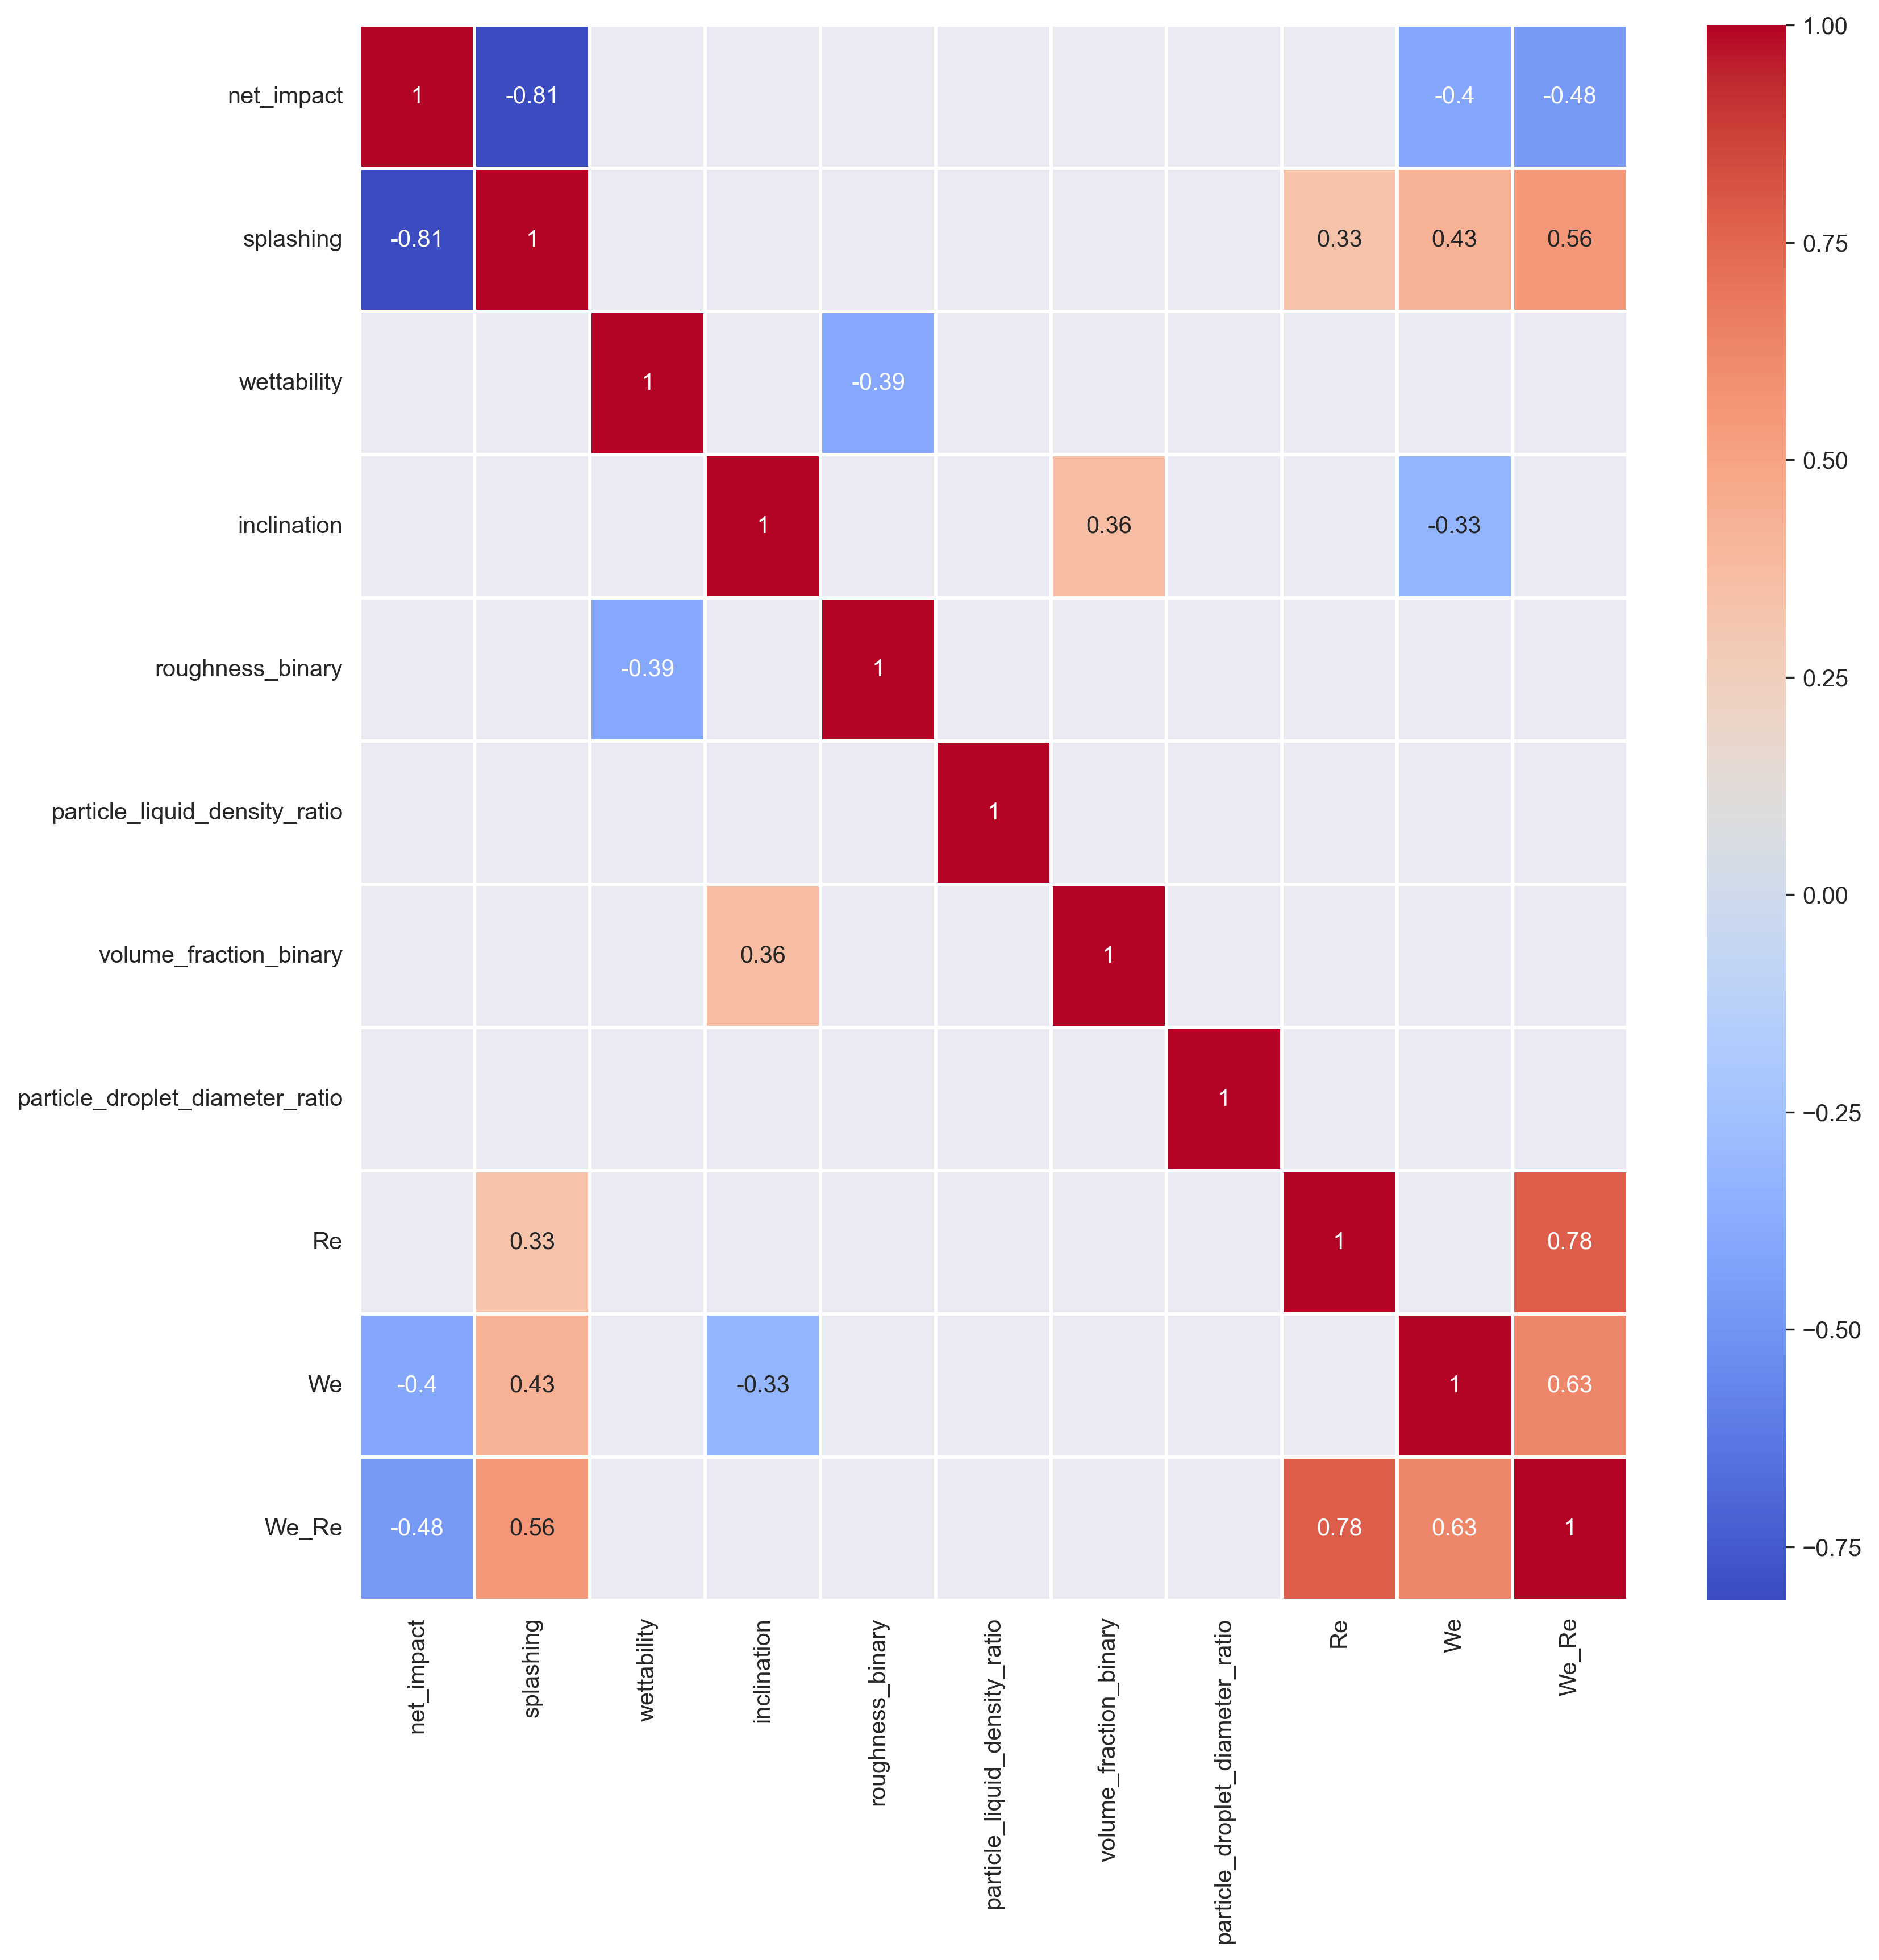

In [12]:
dimension_features = [
    'liquid_density',
    'surface_tension',
    'viscosity',
    'droplet_diameter'
]

df_modelling_dimensionless = df_modelling_no_corr.drop(
    dimension_features, 
    axis=1
)
df_modelling_dimensionless.info()
get_corrmap(df_modelling_dimensionless, thresh=0.3)

### Save dataset for generalized modelling



In [13]:
df_modelling_dimensionless.to_excel(
    '../data/df_modelling_dimensionless.xlsx', 
    index=False,
)